# Checkpoint modifications

Checkpoint modifications can be made to include more outputs or change
certain aspects of the simulations (e.g., changing filters). Here, we
demonstrate how to add an output for surface pressure and how to use a
modified filter that fixes the global mean surface pressure (NeuralGCM
models conserve moisture but not dry air mass; see the discussion in the
[NeuralGCM paper](https://www.nature.com/articles/s41586-024-07744-y)).

In the upstream package (and the legacy port) this is done by appending
gin-config lines to the checkpoint's config string. In
**neuralgcm-torch**, converted checkpoints store the parsed config as
plain data, so modifications are ordinary dict edits — no gin involved.
Mirrors the upstream
[checkpoint_modifications](https://github.com/neuralgcm/neuralgcm/blob/main/docs/checkpoint_modifications.ipynb)
notebook; needs network access (checkpoint + ERA5, both anonymous GCS).

In [2]:
import copy
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray

from dinosaur_torch import horizontal_interpolation
from dinosaur_torch import xarray_utils
import neuralgcm_torch as neuralgcm
from neuralgcm_torch import checkpoint as checkpoint_lib

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Load and inspect the checkpoint config

In [3]:
model_name = 'deterministic_2_8_deg'  #@param ['deterministic_0_7_deg', 'deterministic_1_4_deg', 'deterministic_2_8_deg', 'stochastic_1_4_deg']

from neuralgcm_torch import pretrained
# Fetched from the Hugging Face Hub on first use (cached), or reused from
# a local checkpoints/ directory if present.
converted_path = pretrained.fetch_checkpoint(model_name, local_root='checkpoints')
base_checkpoint = checkpoint_lib.load(converted_path)

## The anatomy of a converted checkpoint

Before editing anything, here is the whole converted checkpoint at a glance — the high-level `config` (just plain Python data you can edit), the auxiliary feature arrays, and the learned-parameter hierarchy with per-subtree counts. Expand any section to drill in.

In [ ]:
# A compact "anatomy" of the converted checkpoint, rendered as a collapsible
# HTML card: high-level stats, the (editable) `config` tree, the auxiliary
# feature arrays, and the learned-parameter hierarchy with per-subtree counts.
import html

from IPython.display import HTML


def _human(n):
    for unit in ('', 'K', 'M', 'B'):
        if abs(n) < 1000:
            return f'{n:.0f}' if unit == '' else f'{n:.2f}{unit}'
        n /= 1000
    return f'{n:.2f}T'


def _leaf(v):
    if isinstance(v, torch.Tensor):
        return f'tensor{tuple(v.shape)}'
    if isinstance(v, np.ndarray):
        return f'array{v.shape}·{v.dtype}'
    if isinstance(v, bool):
        return str(v)
    if isinstance(v, float):
        return f'{v:.4g}'
    if isinstance(v, int):
        return str(v)
    if isinstance(v, (list, tuple)):
        return f'{type(v).__name__}[{len(v)}]'
    if isinstance(v, dict):
        return f'dict·{len(v)}'
    if isinstance(v, str):
        s = v if len(v) <= 48 else v[:45] + '…'
        return f'"{html.escape(s)}"'
    return 'None' if v is None else html.escape(type(v).__name__)


_K = 'color:#1d6fb8;font-weight:600'
_V = 'color:#444;font-family:ui-monospace,monospace;font-size:90%'
_C = 'color:#999'
_PAD = 'margin-left:1.1em;border-left:1px solid #e3e3e3;padding-left:.7em'


def _tree(d, open_depth=1, depth=0, max_depth=2):
    rows = []
    for k, v in d.items():
        key = f'<span style="{_K}">{html.escape(str(k))}</span>'
        if isinstance(v, dict) and v and depth < max_depth:
            op = ' open' if depth < open_depth else ''
            rows.append(
                f'<details{op}><summary>{key} '
                f'<span style="{_C}">·{len(v)}</span></summary>'
                f'{_tree(v, open_depth, depth + 1, max_depth)}</details>')
        else:
            rows.append(f'<div>{key} <span style="{_V}">{_leaf(v)}</span></div>')
    return f'<div style="{_PAD}">{"".join(rows)}</div>'


def _params_tree(params):
    """Nest the flat haiku paths (dropping '~') and sum params per subtree."""
    root, counts = {}, {}
    for path, bundle in params.items():
        parts = [p for p in path.split('/') if p != '~']
        n = sum(int(np.prod(t.shape)) for t in bundle.values())
        node = root
        for i, p in enumerate(parts[:-1]):
            node = node.setdefault(p, {})
            key = '/'.join(parts[:i + 1])
            counts[key] = counts.get(key, 0) + n
        node[parts[-1]] = {kk: tuple(vv.shape) for kk, vv in bundle.items()}
    return root, counts


def _ptree(d, counts, prefix='', depth=0, open_depth=1):
    rows = []
    for k, v in d.items():
        path = f'{prefix}/{k}' if prefix else k
        key = f'<span style="{_K}">{html.escape(str(k))}</span>'
        branch = isinstance(v, dict) and not all(
            isinstance(x, tuple) for x in v.values())
        if branch:
            op = ' open' if depth < open_depth else ''
            rows.append(
                f'<details{op}><summary>{key} <span style="{_C}">· '
                f'{_human(counts.get(path, 0))}</span></summary>'
                f'{_ptree(v, counts, path, depth + 1, open_depth)}</details>')
        else:
            shapes = ', '.join(f'{kk}{vv}' for kk, vv in v.items())
            rows.append(
                f'<div>{key} <span style="{_V}">{html.escape(shapes)}</span></div>')
    return f'<div style="{_PAD}">{"".join(rows)}</div>'


def checkpoint_anatomy(ck, name=''):
    """A collapsible HTML overview of a converted NeuralGCM checkpoint."""
    cfg = ck['config']
    n_par = sum(int(np.prod(t.shape))
                for b in ck['params'].values() for t in b.values())

    def grid(g):
        return (f"{g['longitude_nodes']}×{g['latitude_nodes']} "
                f"· {g['spherical_harmonics']} SH")

    stats = [
        ('format', f"v{ck['format_version']}"),
        ('model grid', grid(cfg['model_grid'])),
        ('data grid', grid(cfg['data_grid'])),
        ('vertical', f"{len(cfg['model_sigma_boundaries']) - 1} σ-levels "
                     f"→ {len(cfg['data_pressure_levels'])} p-levels"),
        ('timestep', f"{cfg['timestep_seconds']:.0f} s · dt={cfg['dt']:.4f}"),
        ('parameters', f"{_human(n_par)} · {len(ck['params'])} bundles"),
        ('gin bindings', f"{len(cfg['model'])} configurables"),
    ]
    chips = ''.join(
        f'<div style="padding:.25em .8em"><div style="font-size:75%;'
        f'color:#7a8aa0;text-transform:uppercase;letter-spacing:.04em">'
        f'{html.escape(k)}</div><div style="font-weight:600;color:#10212f">'
        f'{html.escape(str(v))}</div></div>' for k, v in stats)

    cfg_main = {k: v for k, v in cfg.items()
                if k not in ('gin_config_str', 'model')}
    model_rows = ''.join(
        f'<div><span style="{_K}">{html.escape(k)}</span> '
        f'<span style="{_V}">{_leaf(v)}</span></div>'
        for k, v in cfg['model'].items())
    model_block = (
        f'<details><summary><span style="{_K}">model</span> <span style="{_C}">'
        f'· {len(cfg["model"])} gin configurables (edit these)</span></summary>'
        f'<div style="{_PAD}">{model_rows}</div></details>')
    aux_rows = ''.join(
        f'<div><span style="{_K}">{html.escape(k)}</span> '
        f'<span style="{_V}">{_leaf(v)}</span></div>'
        for k, v in ck['aux_features'].items())
    root, counts = _params_tree(ck['params'])

    return HTML(
        '<div style="font-family:system-ui,sans-serif;max-width:760px;'
        'border:1px solid #dfe6ee;border-radius:12px;overflow:hidden">'
        '<div style="background:linear-gradient(95deg,#0f8f93,#19c08a);'
        'color:#fff;padding:.7em 1em;font-weight:700;font-size:108%">'
        f'NeuralGCM checkpoint · {html.escape(name)}</div>'
        '<div style="display:flex;flex-wrap:wrap;gap:.1em;background:#f6f9fb;'
        f'padding:.5em;border-bottom:1px solid #e6edf3">{chips}</div>'
        '<div style="padding:.6em 1em;font-size:92%">'
        '<details open><summary style="font-weight:600">config '
        '<span style="color:#999">(editable — plain data)</span></summary>'
        f'{_tree(cfg_main)}{model_block}</details>'
        '<details><summary style="font-weight:600">aux_features</summary>'
        f'<div style="{_PAD}">{aux_rows}</div></details>'
        '<details><summary style="font-weight:600">params '
        f'<span style="color:#999">· {_human(n_par)}</span></summary>'
        f'{_ptree(root, counts)}</details></div></div>')


checkpoint_anatomy(base_checkpoint, model_name)

The converted checkpoint's `config['model']` holds the parsed bindings as
plain data: a dict of `'scope/ClassName' -> {parameter: value}` with
references encoded as `{'__ref__': name}`. The pieces we are going to
modify:

In [4]:
bindings = base_checkpoint['config']['model']
print(bindings['dycore/SequentialStepFilter'])
print(bindings['DimensionalLearnedPrimitiveToWeatherbenchDecoder']
      ['inputs_to_units_mapping'])

{'filter_modules': [{'__ref__': 'dycore/ExponentialFilter', '__call__': False}, {'__ref__': 'stability/ExponentialFilter', '__call__': False}], 'name': None}
{'sim_time': 'dimensionless', 't': 'kelvin', 'tracers': {'specific_cloud_ice_water_content': 'dimensionless', 'specific_cloud_liquid_water_content': 'dimensionless', 'specific_humidity': 'dimensionless'}, 'u': 'meter / second', 'v': 'meter / second', 'z': 'm**2 s**-2'}


## Modify the checkpoint

Three edits add a surface pressure output:

1. a step diagnostics module (`SurfacePressureDiagnostics`) that computes
   surface pressure from the model state at every step,
2. a decoder diagnostics module (`NodalModelDiagnosticsDecoder`) that
   passes it into the decoded outputs,
3. an entry in the decoder's units mapping so the output is converted back
   to SI units (Pa).

A fourth, optional edit appends `FixGlobalMeanFilter` to the dycore step
filters, which holds the global mean log surface pressure exactly
constant:

In [5]:
def with_surface_pressure_output(checkpoint, fix_global_mean):
  checkpoint = copy.deepcopy(checkpoint)
  bindings = checkpoint['config']['model']
  ref = lambda name: {'__ref__': name, '__call__': False}

  decoder = 'DimensionalLearnedPrimitiveToWeatherbenchDecoder'
  units = dict(bindings[decoder]['inputs_to_units_mapping'])
  units['diagnostics'] = {'surface_pressure': 'kg / (meter s**2)'}
  bindings[decoder]['inputs_to_units_mapping'] = units
  bindings[decoder]['diagnostics_module'] = ref('NodalModelDiagnosticsDecoder')
  bindings['StochasticPhysicsParameterizationStep']['diagnostics_module'] = (
      ref('SurfacePressureDiagnostics')
  )
  if fix_global_mean:
    bindings['dycore/SequentialStepFilter']['filter_modules'] = list(
        bindings['dycore/SequentialStepFilter']['filter_modules']
    ) + [ref('surface_pressure/FixGlobalMeanFilter')]
  return checkpoint


model_fix = neuralgcm.PressureLevelModel.from_checkpoint(
    with_surface_pressure_output(base_checkpoint, fix_global_mean=True),
    device=device,
)
model_no_fix = neuralgcm.PressureLevelModel.from_checkpoint(
    with_surface_pressure_output(base_checkpoint, fix_global_mean=False),
    device=device,
)

## Initial condition from ERA5

In [6]:
era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
full_era5 = xarray.open_zarr(
    era5_path, chunks=None, storage_options=dict(token='anon')
)
variables = model_fix.input_variables + model_fix.forcing_variables
sliced_era5 = full_era5[variables].sel(time='2020-02-14T00').compute()

era5_grid = xarray_utils.grid_spec_from_dataset(full_era5)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model_fix.data_grid, skipna=True, device=device
)
eval_era5 = xarray_utils.regrid_horizontal(sliced_era5, regridder)
eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

## Run both models for a month

A 30-day integration with daily outputs, using persistent forcings.
`surface_pressure` now appears among the outputs:

In [7]:
outer_steps = 30
timedelta = np.timedelta64(24, 'h')
times = np.arange(outer_steps)  # time axis in days


def month_long_run(model):
  inputs = model.inputs_from_xarray(eval_era5)
  forcings = model.forcings_from_xarray(eval_era5)
  state = model.encode(inputs, forcings, rng=42)
  _, predictions = model.unroll(
      state, forcings, steps=outer_steps, timedelta=timedelta,
      start_with_input=True,
  )
  return model.data_to_xarray(predictions, times=times)


predictions_fix = month_long_run(model_fix)
predictions_no_fix = month_long_run(model_no_fix)
list(predictions_fix.data_vars)

['u_component_of_wind',
 'v_component_of_wind',
 'temperature',
 'geopotential',
 'specific_humidity',
 'specific_cloud_ice_water_content',
 'specific_cloud_liquid_water_content',
 'surface_pressure']

## Compare global mean log surface pressure

The area-weighted global mean of log surface pressure (proportional to the
`(0, 0)` spherical-harmonic coefficient that `FixGlobalMeanFilter` pins)
stays constant in the modified model. Without the filter it is not held
fixed and drifts slightly over the month (here by about 0.05%) — a small
numerical effect that the filter removes:

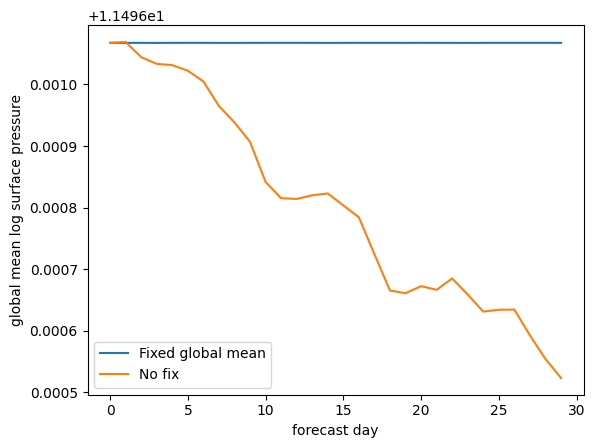

In [8]:
weights = xarray.DataArray(
    model_fix.data_grid.quadrature_weights, dims='latitude'
)


def global_mean_log_sp(predictions):
  return np.log(predictions.surface_pressure).weighted(weights).mean(
      ['longitude', 'latitude']
  )


plt.plot(times, global_mean_log_sp(predictions_fix), label='Fixed global mean')
plt.plot(times, global_mean_log_sp(predictions_no_fix), label='No fix')
plt.xlabel('forecast day')
plt.ylabel('global mean log surface pressure')
plt.legend();